In [1]:
import torch
import numpy as np
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {device}")

Running on: cuda


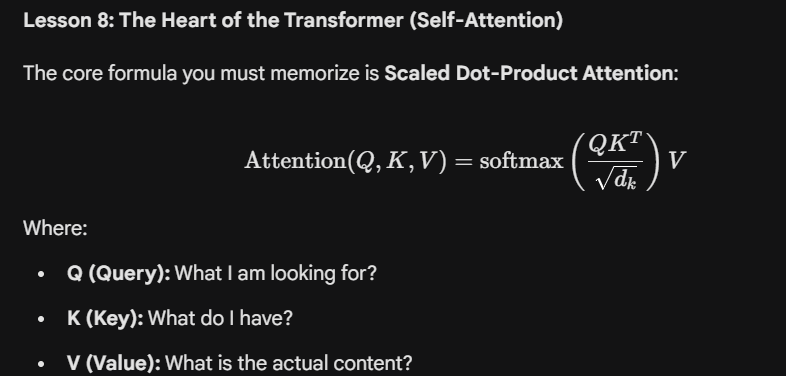

### The Mechanics (Matrix Multiplication)

In standard neural nets (MLPs/CNNs), weights are fixed after training. In Attention, the "weights" (the attention scores) are dynamic. They change depending on the input data.

**Example:** If you input the sentence "The bank of the river":

- The word "bank" (Query) asks all other words "are you related to me?"
- The word "river" (Key) shouts "YES!" (High dot product score).
- The word "money" (if it existed) would whisper "No" (Low dot product score).

In [2]:
#We will implement a single head of attention without using nn.MultiheadAttention.
import torch.nn.functional as F
import math

class SelfAttentionHead(nn.Module):
    def __init__(self, d_model, head_size):
        super().__init__()
        # 1. The Projections (Linear layers without bias usually)
        self.key = nn.Linear(d_model, head_size, bias=False)
        self.query = nn.Linear(d_model, head_size, bias=False)
        self.value = nn.Linear(d_model, head_size, bias=False)
        
        self.head_size = head_size

    def forward(self, x):
        # x shape: (Batch_Size, Sequence_Length, d_model)
        B, T, C = x.shape
        
        # 2. Project inputs to Q, K, V
        k = self.key(x)   # (B, T, head_size)
        q = self.query(x) # (B, T, head_size)
        v = self.value(x) # (B, T, head_size)
        
        # 3. Compute Attention Scores (Affinities)
        # We want (B, T, head_size) @ (B, head_size, T) -> (B, T, T)
        # transpose(-2, -1) swaps the last two dimensions
        weights = q @ k.transpose(-2, -1) 
        
        # 4. Scale (Stability trick)
        weights = weights / math.sqrt(self.head_size)
        
        # 5. Masking (Optional, for Decoder/GPT style)
        # We mask out future tokens so they can't "cheat"
        # tril = lower triangular matrix
        tril = torch.tril(torch.ones(T, T)).to(x.device)
        weights = weights.masked_fill(tril == 0, float('-inf'))
        
        # 6. Softmax (Convert scores to probabilities)
        weights = F.softmax(weights, dim=-1)
        
        # 7. Weighted Aggregation
        # (B, T, T) @ (B, T, head_size) -> (B, T, head_size)
        out = weights @ v
        
        return out

# Usage
# Batch=1, Seq_Len=4 (words), Embedding_Dim=8
x = torch.randn(1, 4, 8) 
sa_head = SelfAttentionHead(d_model=8, head_size=16)
output = sa_head(x)
print(output.shape) # Should be (1, 4, 16)

torch.Size([1, 4, 16])


### Multi-Head Attention

A single head is weak. A Transformer uses **Multi-Head Attention** (running several heads in parallel and concatenating the results).

In [3]:
# --- 1. The Single Head (From Previous Lesson) ---
class SelfAttentionHead(nn.Module):
    def __init__(self, d_model, head_size):
        super().__init__()
        self.key = nn.Linear(d_model, head_size, bias=False)
        self.query = nn.Linear(d_model, head_size, bias=False)
        self.value = nn.Linear(d_model, head_size, bias=False)
        self.head_size = head_size

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)
        q = self.query(x)
        v = self.value(x)
        
        # Calculate attention scores
        weights = q @ k.transpose(-2, -1) * (self.head_size ** -0.5)
        
        # Masking (Make it causal/autoregressive)
        tril = torch.tril(torch.ones(T, T)).to(x.device)
        weights = weights.masked_fill(tril == 0, float('-inf'))
        
        weights = F.softmax(weights, dim=-1)
        
        return weights @ v

# --- 2. The Multi-Head Wrapper (The Assignment) ---
class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size, d_model):
        super().__init__()
        self.heads = nn.ModuleList([
            SelfAttentionHead(d_model, head_size) for _ in range(num_heads)
        ])
        
        # Project back to original dimension after concatenation
        # Input to this layer will be (num_heads * head_size)
        self.proj = nn.Linear(num_heads * head_size, d_model)
        
        # Dropout is often added here in research papers
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        # 1. Run all heads in parallel (List Comprehension)
        # Each head outputs (B, T, head_size)
        out = [h(x) for h in self.heads]
        
        # 2. Concatenate over the last dimension (Feature dimension)
        # Result shape: (B, T, num_heads * head_size)
        out = torch.cat(out, dim=-1)
        
        # 3. Project and Dropout
        out = self.proj(out)
        out = self.dropout(out)
        
        return out

# --- 3. Verification ---

# Hyperparameters
D_MODEL = 32      # Embedding dimension
NUM_HEADS = 4     # 4 parallel heads
HEAD_SIZE = 8     # Each head looks at 8-dim subspace (4 * 8 = 32)

# Create Dummy Data (Batch=1, Seq_Len=10 words, Embed_Dim=32)
x = torch.randn(1, 10, D_MODEL)

# Instantiate
mha = MultiHeadAttention(NUM_HEADS, HEAD_SIZE, D_MODEL)

# Forward Pass
output = mha(x)

print(f"Input Shape: {x.shape}")
print(f"Output Shape: {output.shape}") 
# Output should match Input shape (1, 10, 32) because of the projection layer

Input Shape: torch.Size([1, 10, 32])
Output Shape: torch.Size([1, 10, 32])


### Important: Use `nn.ModuleList`, not a regular Python list `[]`

**Wrong:**
```python
self.heads = [SelfAttentionHead(...) ...]
```

PyTorch will not see these layers. Their parameters will not be included in `model.parameters()`, so `optimizer.step()` will not update them.

**Correct:**
```python
self.heads = nn.ModuleList([...])
```

This registers the list of sub-modules with the parent model correctly.